![logo](../../../LogoLine_horizon_C3S.png)

# Satellite Land Cover trend assessment for Spatial Planning and Land Management

Production date: 20-12-2024

Produced by: Inês Girão (+ATLANTIC)

## 🌍 Use case: Using land cover products to quantify afforestation/deforestation trends

## ❓ Quality assessment question
* **Is the dataset suitable for the analysis of afforestation/deforestation trends in the Iberian Peninsula?**


Land Cover data is an invaluable resource for a wide range of fields, from climate change research to forest management. Land Cover products that provide historical timelines enable scientists, policymakers, and planners to understand and analyse the transformation of land cover over recent decades ([EUROSTAT,2022](https://ec.europa.eu/eurostat/statistics-explained/index.php?title=Forests,_forestry_and_logging); [New EU Forest Strategy for 2030](https://commission.europa.eu/document/cf3294e1-8358-4c93-8de4-3e1503b95201_en)).

This notebook will access the ***Land cover classification gridded maps from 1992 to present derived from satellite observations*** (henceforth, LC) data from the Climate Data Store (CDS) of the Copernicus Climate Change Service (C3S), and analyse the spatial patterns of a specific LC type over a given Area of Interest (AoI) and time.

## 📢 Quality assessment statement

```{admonition} These are the key outcomes of this assessment
:class: note
The dataset maintains strong temporal continuity, with annual updates ensuring a smooth and reliable representation of forest land cover changes over time. While breakpoints were identified, they generally did not indicate major disruptions, reinforcing the dataset’s stability for long-term trend analysis.

The presence of breakpoints does not necessarily indicate abrupt landscape shifts but rather highlights the sensitivity of detection methods to gradual changes. This suggests that while breakpoints can help refine analysis, their impact on overall trends remains limited, emphasising the dataset’s resilience to minor variations.

For the specific land cover type analysed, the dataset exhibits a consistent ability to capture underlying trends. The similarity in results across segmented and total trends suggests that the data structure is well-calibrated, minimising distortions that could arise from classification inconsistencies or methodological biases.

```

![Forest_Map_Series.png](Forest_Map_Series.png)

## 📋 Methodology

**This Use Case comprises the following steps:**

**[](satellite_satellite-land-cover_completeness_q03:code-section-1)**

**[](satellite_satellite-land-cover_completeness_q03:code-section-2)**

**[](satellite_satellite-land-cover_completeness_q03:code-section-3)**

**[](satellite_satellite-land-cover_completeness_q03:code-section-4)**

**[](satellite_satellite-land-cover_completeness_q03:code-section-5)**

## 📈 Analysis and results

(satellite_satellite-land-cover_completeness_q03:code-section-1)=
### **1. Define the AoI, search and download LC data**
Before we begin we must prepare our environment. This includes installing the Application Programming Interface (API) of the CDS, and importing the various python libraries that we will need.

#### Install CDS API
To install the CDS API, run the following command. We use an exclamation mark to pass the command to the shell (not to the Python interpreter).
If you already have the CDS API installed, you can skip or comment this step.

In [1]:
!pip install cdsapi

Defaulting to user installation because normal site-packages is not writeable


##### Import all the libraries/packages

We will be working with data in NetCDF format. To best handle this type of data we will use libraries for working with multidimensional arrays, in particular Xarray. 
We will also need libraries for plotting and viewing data.

In [2]:
#  Import Standard Libraries
import random
from collections import defaultdict

#  Import Numerical & Statistical Libraries
import numpy as np
import pandas as pd
import xarray as xr
import dask
from scipy.stats import linregress, f, kendalltau, theilslopes
from statsmodels.api import OLS
from numpy.polynomial.polynomial import Polynomial
import pymannkendall as mk

# import ruptures as rpt
import ruptures as rpt
from scipy.optimize import curve_fit
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import r2_score
from scipy.signal import savgol_filter

#  Import Geospatial Libraries
import geopandas as gpd  # Import vector geospatial data
import regionmask  # Transform attributes and geometries into specific regions
from shapely.geometry import box, Polygon


#  Import Visualization Libraries
import matplotlib.pyplot as plt
import matplotlib.colors as colors
from matplotlib.colors import TwoSlopeNorm, Normalize
from matplotlib.patches import Patch
from IPython.display import display
from matplotlib.lines import Line2D
from collections import defaultdict
from IPython.display import display, HTML

#  Import External Tools
from c3s_eqc_automatic_quality_control import download, plot, utils


#  Set Matplotlib Style
plt.style.use("seaborn-v0_8-notebook")  # Predefined style for all graphical outputs

# Set the CDSAPI location
import os
os.environ["CDSAPI_RC"] = "/data/wp5/girao_ines/.cdsapirc"

##### Data Overview

To search for data, visit the CDS website: http://cds.climate.copernicus.eu Here you can search for 'Satellite observations' using the search bar. The data we need for this tutorial is the ***Land cover classification gridded maps from 1992 to present derived from satellite observations***. This catalogue entry provides global Land Cover Classification (LCC) maps with a very high spatial resolution, with a L4 processing level, on an annual basis with a one-year delay, following the [Global Climate Observing System (GCOS) convention requirements](https://library.wmo.int/records/item/58111-the-2022-gcos-ecvs-requirements-gcos-245). LULC maps correspond to a global classification scheme, encompassing 22 classes.

The dataset consists of 2 versions (v2.0.7 produced by the European Space Agency (ESA) Climate Change Initiative (CCI) and v2.1.1 produced by Copernicus Climate Change Service (C3S)).

Data specifications for this use case:
* **Years:** 1992 to 2022
* **Version:** v2.0.7 before 1992 and v2.1.1 after 2016
* **Format:** Zip files

At the end of the download form, select “**Show API request**”. This will reveal a block of code, which you can simply copy and paste into a cell of your Jupyter Notebook. Having copied the API request, running it will retrieve and download the data you requested into your local directory. However, before you run it, the **terms and conditions** of this particular dataset need to have been accepted directly at the CDS website. The option to view and accept these conditions is given at the end of the download form, just above the “**Show API request**” option. In addition, it is also useful to define the time period and AoI parameters and edit the request accordingly, as exemplified in the cells below.

In [3]:
#Years to download
years = [1992, 1993, 1994,
        1995, 1996, 1997,
        1998, 1999, 2000,
        2001, 2002, 2003,
        2004, 2005, 2006,
        2007, 2008, 2009,
        2010, 2011, 2012,
        2013, 2014, 2015,
        2016, 2017, 2018,
        2019, 2020, 2021,
        2022, 2022]


# List of requests to retrieve data
collection_id = "satellite-land-cover"
requests = [
    {
        "variable": "all",
        "format": "zip",
        "version": "v2_0_7cds" if year < 2016 else "v2_1_1",
        "year": str(year),
        "area": [45, -10, 35, 4] # Region of interest (Iberian Peninsula)
    }
    for year in years
]

In [4]:
# Download the dataset
ds = download.download_and_transform(
    collection_id,
    requests,
    n_jobs=2
)
ds = ds.assign_coords(year=ds["time"].dt.year).swap_dims(time="year").drop("time")

100%|██████████| 32/32 [00:00<00:00, 88.34it/s] 
/data/common/miniforge3/envs/wp5/lib/python3.12/site-packages/earthkit/data/readers/netcdf/fieldlist.py:202: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  return xr.open_mfdataset(
/data/wp5/.tmp/ipykernel_11804/1703755849.py:7: DeprecationWarning: dropping variables using `drop` is deprecated; use drop_vars.
  ds = ds.assign_coords(year=ds["time"].dt.year).swap_dims(time="year").drop("time")


In [5]:
#Inspect the database
ds

<xarray.Dataset> Size: 7GB
Dimensions:              (year: 31, latitude: 3600, longitude: 5040, bounds: 2)
Coordinates:
  * year                 (year) int64 248B 1992 1993 1994 ... 2020 2021 2022
  * latitude             (latitude) float64 29kB 45.0 45.0 44.99 ... 35.0 35.0
  * longitude            (longitude) float64 40kB -9.999 -9.996 ... 3.996 3.999
    lat_bounds           (latitude, bounds, longitude) float64 290MB dask.array<chunksize=(1200, 1, 1680), meta=np.ndarray>
    lon_bounds           (longitude, bounds) float64 81kB dask.array<chunksize=(5040, 2), meta=np.ndarray>
    time_bounds          (year, bounds, longitude) datetime64[ns] 2MB dask.array<chunksize=(1, 2, 5040), meta=np.ndarray>
Dimensions without coordinates: bounds
Data variables:
    lccs_class           (year, latitude, longitude) uint8 562MB dask.array<chunksize=(1, 1800, 2520), meta=np.ndarray>
    processed_flag       (year, latitude, longitude) float32 2GB dask.array<chunksize=(1, 1800, 2520), meta=np.ndarray>
    current_pixel_state  (year, latitude, longitude) float32 2GB dask.array<chunksize=(1, 1800, 2520), meta=np.ndarray>
    observation_count    (year, latitude, longitude) uint16 1GB dask.array<chunksize=(1, 1800, 2520), meta=np.ndarray>
    change_count         (year, latitude, longitude) uint8 562MB dask.array<chunksize=(1, 1800, 2520), meta=np.ndarray>
    crs                  (year, longitude) int32 625kB dask.array<chunksize=(1, 5040), meta=np.ndarray>
Attributes: (12/38)
    id:                         ESACCI-LC-L4-LCCS-Map-300m-P1Y-1992-v2.0.7cds
    title:                      Land Cover Map of ESA CCI brokered by CDS
    summary:                    This dataset characterizes the land cover of ...
    type:                       ESACCI-LC-L4-LCCS-Map-300m-P1Y
    project:                    Climate Change Initiative - European Space Ag...
    references:                 http://www.esa-landcover-cci.org/
    ...                         ...
    geospatial_lon_max:         180
    spatial_resolution:         300m
    geospatial_lat_units:       degrees_north
    geospatial_lat_resolution:  0.002778
    geospatial_lon_units:       degrees_east
    geospatial_lon_resolution:  0.002778

(satellite_satellite-land-cover_completeness_q03:code-section-2)=
### **2. Inspect and view data for the defined AoI (Iberian Peninsula)**
#### Compute Land Cover classes area coverage for each NUTS 2 region

To identify changes in LC patterns, by regions, NUTS 2 will be used, providing the information regarding the main regions of Iberian Peninsula.

The NUTS are a hierarchical system divided into 3 levels (https://ec.europa.eu/eurostat/web/nuts). NUTS 1 correspond to major socio-economic regions, NUTS 2 correspond to basic regions for the application of regional policies, and NUTS 3 correspond to small regions for specific diagnoses. Additionally a NUTS 0 level, usually co-incident with national boundaries is also available. The NUTS legislation is periodically amended; therefore multiple years are available for download. 

#### Mask regions

First, we need to establish the geometry of the NUTS region (level 2) in order to make the corresponding statistics.

In [6]:
# Configure Dask
dask.config.set(scheduler='threads', **{'array.slicing.split_large_chunks': True})

# Define CRS and bounding box for Iberian Peninsula
crs_wgs84 = "EPSG:4326"
iberian_bbox = box(-10, 36, 3.5, 44)

# Load and filter GeoDataFrame
shapefile_url = "https://gisco-services.ec.europa.eu/distribution/v2/nuts/shp/NUTS_RG_20M_2021_4326.shp.zip"
gdf = gpd.read_file(shapefile_url)
gdf = gdf[gdf["LEVL_CODE"] == 2]
gdf = gdf[gdf["NUTS_ID"].str.startswith(("ES", "PT"))]  # Spain (ES) and Portugal (PT)
gdf = gdf.to_crs(crs_wgs84)
gdf = gdf[gdf.intersects(iberian_bbox)]
gdf = gdf[gdf.geometry.is_valid & ~gdf.geometry.is_empty]

if gdf.empty:
    raise ValueError("No valid geometries found after filtering.")

# Ensure dataset CRS is set
if ds.rio.crs is None:
    ds = ds.rio.write_crs("EPSG:4326", inplace=True)

# Ensure dataset coordinates overlap with the filtered regions
filtered_lon_min, filtered_lat_min, filtered_lon_max, filtered_lat_max = gdf.total_bounds
if (
    ds["longitude"].min().values > filtered_lon_max
    or ds["longitude"].max().values < filtered_lon_min
    or ds["latitude"].min().values > filtered_lat_max
    or ds["latitude"].max().values < filtered_lat_min
):
    raise ValueError(
        "Dataset coordinates do not overlap with the filtered regions. Check dataset and region alignment."
    )

# Subset dataset to valid ranges
ds = ds.sel(
    longitude=slice(
        max(filtered_lon_min, ds["longitude"].min().values),
        min(filtered_lon_max, ds["longitude"].max().values)
    ),
    latitude=slice(
        min(filtered_lat_max, ds["latitude"].max().values),
        max(filtered_lat_min, ds["latitude"].min().values)
    )
)

# Check subset dataset dimensions
if ds["longitude"].size == 0 or ds["latitude"].size == 0:
    raise ValueError("Subset resulted in an empty dataset. Check the bounds and ensure overlap.")

# Create the regionmask
regions = regionmask.from_geopandas(gdf, names="NUTS_NAME")

# Create a 2D mask
mask = regions.mask(ds["longitude"], ds["latitude"])

ds= ds.where(mask.notnull(), drop=True)

#### Compute cell area

Then, we can calculate the area of each pixel taking into consideration the curvature of the earth (i.e., weighted by the cosine of Latitude).

In [7]:
# Scaling factor for conversion (constant longitude resolution)
scaling_factor = 0.002778  # Degrees
resolution_lon_km = scaling_factor * 111.195  # Longitude resolution in kilometres

# Use the latitude values directly from the dataset
lats = ds["latitude"]

# Calculate the difference between consecutive latitude values
lat_diff = np.abs(np.diff(lats.values))  # Absolute differences
lat_diff = np.append(lat_diff, lat_diff[-1])  # Assume the last cell has the same size as the one before

# Convert latitude differences to kilometres
resolution_lat_km = lat_diff * 111.195  # Latitude-dependent resolution

# Compute the grid cell area for each latitude
grid_cell_area = resolution_lon_km * resolution_lat_km * np.cos(np.radians(lats))

# Assign attributes to the grid cell area
grid_cell_area.attrs = {
    "standard_name": "cell_area",
    "long_name": "Grid cell area",
    "units": "km²",
}

# Add the grid cell area as a coordinate to the dataset
ds = ds.assign_coords(cell_area=("latitude", grid_cell_area.data))  # Use `.data` to extract the array


#### Select Forest Classes and Prepare Dataset

To analyse forest cover, we selected all land cover (LC) classes corresponding to forest types from the LC dataset. The classes are described in the [(C3S, LC - Product User Guide and Specification (2024)](https://dast.copernicus-climate.eu/documents/satellite-land-cover/WP2-FDDP-LC-2021-2022-SENTINEL3-300m-v2.1.1_PUGS_v1.1_final.pdf).

The following class codes were included:

- **50** – Tree cover, broadleaved, evergreen  
- **60** – Tree cover, broadleaved, deciduous, closed  
- **61** – Tree cover, broadleaved, deciduous, open  
- **62** – Tree cover, broadleaved, deciduous  
- **70** – Tree cover, needleleaved, evergreen  
- **71** – Tree cover, needleleaved, evergreen, closed  
- **72** – Tree cover, needleleaved, evergreen, open  
- **80** – Tree cover, needleleaved, deciduous  
- **81** – Tree cover, needleleaved, deciduous, closed  
- **82** – Tree cover, needleleaved, deciduous, open  
- **90** – Tree cover, mixed leaf type  
- **100** – Mosaic tree and shrub / herbaceous cover  
- **160** – Tree cover, flooded, fresh or brackish water  
- **170** – Tree cover, flooded, saline water  

All these classes were aggregated to represent **forest cover** in the analysis.

In [8]:
# Define forest classes
forest_classes = [50, 60, 61, 62, 70, 71, 72, 80, 81, 82, 90, 100, 160, 170]

# Create a mask for forested areas
forest_mask = ds['lccs_class'].isin(forest_classes)

# Masked forest area using cell area
ds_Forest_Area = ds['cell_area'].where(forest_mask)

# Stack latitude and longitude into a single dimension
ds_Forest_Area = ds_Forest_Area.stack(stacked_lat_lon=("latitude", "longitude"))

# Create a stacked mask and align dimensions
stacked_mask = mask.stack(stacked_lat_lon=("latitude", "longitude"))
stacked_mask.name = "stacked_mask"

# Attach the stacked mask to the dataset
ds_Forest_Area = ds_Forest_Area.assign_coords(stacked_mask=stacked_mask)

# Group by regions and compute forested area for each year
Forest_Area_by_region = (
    ds_Forest_Area.groupby("stacked_mask")
    .sum(dim="stacked_lat_lon")
    .compute()
)

#### Compute forest area per region and year

In [9]:
results = []
growth = {}

for reg, reg_area in Forest_Area_by_region.groupby("stacked_mask"):
    if np.isnan(reg):  # Skip NaN regions
        continue

    # Ensure valid region indexing and naming
    region_name = regions[int(reg)].name
    years = ds_Forest_Area['year'].values
    values = reg_area.values.flatten()  # Flatten in case of higher-dimensional arrays

    # Save growth data by year
    if len(values) > 0:
        growth[region_name] = {int(year): float(value) for year, value in zip(years, values)}
    else:
        growth[region_name] = {}  # Handle regions with no data

    # Add results to the list
    for year, value in zip(years, values):
        results.append({
            "Region": region_name,
            "Year": int(year),
            "Forest_Area": float(value)
        })

# Convert results to a DataFrame
results_df = pd.DataFrame(results)

# Add geometry to results_df
if 'NUTS_NAME' in gdf.columns:
    results_df = pd.merge(results_df, gdf[['NUTS_NAME', 'geometry']], left_on="Region", right_on="NUTS_NAME", how="left")
else:
    print("Warning: NUTS_NAME column not found in gdf.")

# Ensure results_df is a GeoDataFrame
if not isinstance(results_df, gpd.GeoDataFrame):
    results_df = gpd.GeoDataFrame(results_df, geometry=gpd.GeoSeries(results_df['geometry']), crs="EPSG:4326")

#### Map forest percentage coverage over-time by NUTS regions in the AoI

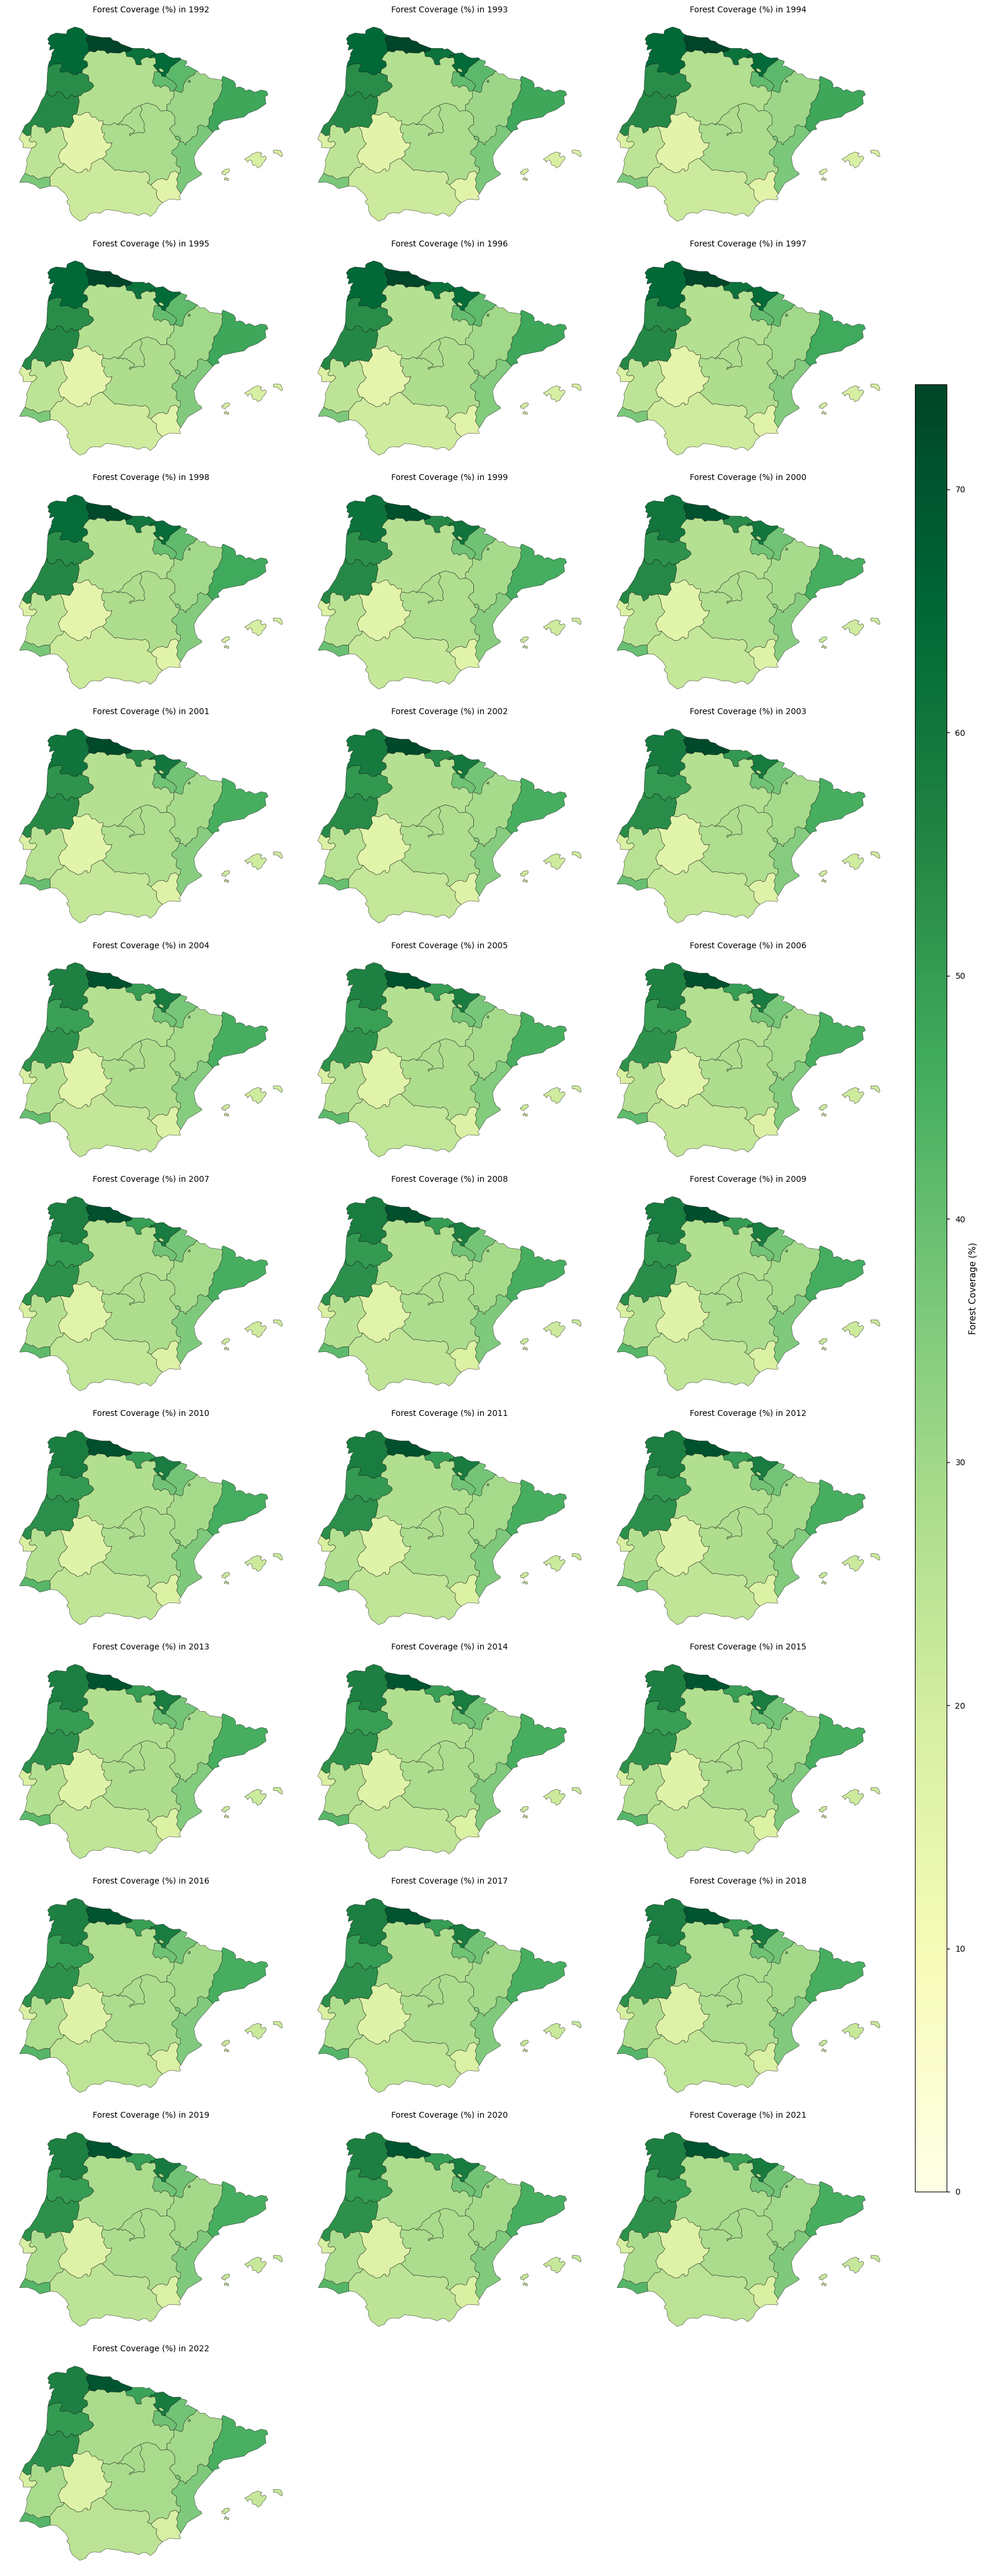

In [10]:
# Reproject the GeoDataFrame to a projected CRS (EPSG:3035 is a good choice for Europe)
results_df = results_df.to_crs("EPSG:3035")

# Calculate the total area of each region (in square kilometers)
results_df["Region_Total_Area"] = results_df.geometry.area / 10**6  # Convert from m² to km²

# Ensure 'Year' is converted to string if needed
results_df['Year'] = results_df['Year'].astype(str)

#Calculate Forest Percentage
results_df['Forest_Percentage'] = (results_df['Forest_Area'] / results_df['Region_Total_Area']) * 100

# Pivot the data to have years as columns
forest_pivot = results_df.pivot(index='Region', columns='Year', values='Forest_Percentage').reset_index()

# Extract years for plotting
years = [col for col in forest_pivot.columns if col.isdigit()]

# Normalize color scale across all maps based on percentage coverage
norm_percentage = Normalize(vmin=0, vmax=results_df['Forest_Percentage'].max())

# Plot settings
n_cols = 3
n_rows = int(np.ceil(len(years) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 6, n_rows * 4), squeeze=False)

# Plot each year in a separate subplot
for idx, year in enumerate(years):
    row, col = divmod(idx, n_cols)
    ax = axes[row, col]
    results_df_year = results_df[results_df['Year'] == year]
    results_df_year.plot(column='Forest_Percentage', cmap="YlGn", ax=ax, edgecolor="k", norm=norm_percentage)
    ax.set_title(f"Forest Coverage (%) in {year}", fontsize=10)
    ax.axis('off')

# Hide unused subplots
for idx in range(len(years), n_rows * n_cols):
    row, col = divmod(idx, n_cols)
    axes[row, col].axis('off')

# Step 8: Adjust layout
plt.tight_layout()

# Allocate space for the color bar
fig.subplots_adjust(right=0.85)
cbar_ax = fig.add_axes([0.87, 0.15, 0.03, 0.7])  # Create a new axes for color bar

# Create a single ScalarMappable object for the common colorbar
sm_common = plt.cm.ScalarMappable(cmap="YlGn", norm=norm_percentage)
sm_common._A = []  # Dummy array for the scalar mappable
fig.colorbar(sm_common, cax=cbar_ax, label="Forest Coverage (%)")

plt.show()

#### Map Analysis

- Over the 28-year period, all regions maintain a consistent area of forest.

- Regions such as Principado de Asturias, Cantabria, País Vasco, Galicia, and Centro (PT) consistently exhibit the highest levels of forest coverage.

- Northern Spain (Galicia, Asturias, Cantabria, País Vasco) is often affected by negative fluctuations, particularly in 1998–2000 and 2003–2004. The classification models may have struggled with complex topography and mixed vegetation types [(Zhao et al., 2023)](https://doi.org/10.3390/rs15092285). 

- Southern Portugal & Spain (Alentejo, Algarve, Andalucía), unlike northern Spain, experiences more positive fluctuations in area, particularly in 1998-2004.

- From 2006–2007 onward the maps show more stable estimates.

#### **Potential Drivers and Methodological Considerations in Afforestation/Deforestation Trends in the Iberian Peninsula (1992–2022)**

Forest dynamics in the Iberian Peninsula over the last three decades have been shaped by a combination of **natural events**, **human activities**, and **policy interventions**. Before analysing trends in a land use and land cover (LULC) time series, it is crucial to account for abrupt shifts that may distort trend estimates. These shifts, often referred to as breakpoints, can result from:

**Natural Events**

- Wildfires:  The Iberian Peninsula experiences frequent and intense wildfires, particularly in **Galicia, Catalonia, and central Portugal**. Major fire seasons occurred in **2003, 2005, and 2017**, causing the destruction of vast areas of forest [(Mato et al., 2014)](https://api.semanticscholar.org/CorpusID:265869582). Wildfires have become a key driver of land cover change, especially in fire-prone regions of Portugal and Spain [(Silva et al., 2011)](https://doi.org/10.1016/j.landurbplan.2011.03.001).  

- Droughts:  Recurrent droughts have exacerbated forest degradation, weakening tree resilience and delaying post-fire recovery [(Gouveia et al., 2012)](https://nhess.copernicus.org/articles/12/3123/2012/). The severe droughts of **2005 and 2017** significantly reduced vegetation cover, affecting Mediterranean pine and oak forests [(Vidal-Macua et al., 2017)](https://doi.org/10.1016/j.foreco.2017.10.011).  

**Human Activities** 

- Farmland Abandonment: Rural depopulation since the 1990s has driven widespread farmland abandonment, leading to natural forest regeneration in regions like **northern Portugal and Galicia** [(Palmero-Iniesta et al., 2021)](https://api.semanticscholar.org/CorpusID:238829360).  

- Logging and Eucalyptus Plantations:  Logging activities and the expansion of eucalyptus plantations in **Galicia and central Portugal** have caused periodic forest loss and regrowth [(Silva et al., 2011)](https://doi.org/10.1016/j.landurbplan.2011.03.001).  

**Policy and Economic Influences**

- Afforestation and Reforestation: EU-funded afforestation programs under the **Common Agricultural Policy (CAP)** promoted the planting of trees on abandoned farmland, particularly in **Castilla y León, Extremadura, and parts of Portugal**, leading to abrupt increases in forest cover [(Sevillano et al., 2018)](https://doi.org/10.1016/j.landusepol.2018.06.054). 

- Natura 2000 Network and Conservation Policies: The **Natura 2000 network** has contributed to forest conservation efforts, particularly in regions like **Sierra de Guadarrama (Madrid)** and **Peneda-Gerês National Park (Portugal)** [(Regos et al., 2015)](https://doi.org/10.1016/j.jag.2014.11.010).  

- Economic Downturn (2008–2013):  The economic crisis reduced logging temporarily alleviating deforestation pressures (Mateus & Fernandes, 2014).  


**Methodology**

- Certain shifts in forest land cover may be related to data collection and processing rather than actual forest changes. For instance, transitions between different satellite sensors can introduce artificial breaks in the time series [(Chelali et al., 2019)](https://doi.org/10.1109/JURSE.2019.8808967).

- **The LC dataset is generated from a multi-sensor surface reflectance time series derived from several satellite missions. As sensor technology evolved, different instruments were used to produce consistent global composites.**

<div style="display: flex; justify-content: center;">

| Surface Reflectance (SR) Input | Reference Period | Satellite Sensor / Mission | Main Characteristics |
|---|---|---|---|
| AVHRR SR composites | 1992–1999 | AVHRR-2 (NOAA-11, NOAA-14) | ~1 km spatial resolution, visible and near-infrared observations |
| SPOT-VGT SR composites | 1999–2013 | SPOT-4 / SPOT-5 VEGETATION | 1 km spatial resolution, 4 spectral bands (blue, red, NIR, SWIR) |
| MERIS SR composites | 2003–2012 | Envisat MERIS | ~300 m spatial resolution, 15 spectral bands in visible and near-infrared |
| PROBA-V SR composites | 2013–2019 | PROBA-V | ~300 m spatial resolution, 4 spectral bands (blue, red, NIR, SWIR) |
| Sentinel-3 SR composites | 2020 | Sentinel-3 OLCI | ~300 m spatial resolution, multispectral observations |
| Sentinel-3 SR composites | 2021–2022 | Sentinel-3 OLCI + SLSTR | Optical and thermal observations supporting land-cover mapping |
</div>
<div style="text-align: center;">
Source: See Figure 1-3 in <a href="https://cds.climate.copernicus.eu/datasets/satellite-land-cover?tab=documentation">C3S, LC - Product User Guide and Specification (2024)</a>
</div>

- In addition to optical surface reflectance observations, auxiliary datasets are used to improve land-cover mapping. In particular, **Envisat ASAR Wide Swath Mode (WSM)** radar observations (2005–2012) are incorporated as ancillary information [(C3S - LC Target Requirements and Gap Analysis Document, 2024)](https://dast.copernicus-climate.eu/documents/satellite-land-cover/WP3-TR-GAD-2023_LC_v1.1_final.pdf).

- While the dataset relies on multiple satellite sensors, it is not generated through simple sensor-to-sensor transitions. Instead, the global land-cover time series is built around a baseline land-cover map derived from MERIS observations (2003–2012). Earlier periods (1992–2003) are reconstructed through back-dating using AVHRR and SPOT-VGT data, while later years are produced through incremental updates using SPOT-VGT, PROBA-V, and Sentinel-3 observations. During several periods, multiple sensors are used simultaneously, with different roles (e.g., temporal consistency versus spatial refinement).

<div style="display: flex; justify-content: center;">

| Global LC database | Reference period | Satellite data source |
|---|---|---|
| Baseline 10-year global LC map | 2003–2012 | • MERIS FR/RR global SR composites between 2003 and 2012 |
| Global annual LC maps | 1992–1999 | • Baseline 10-year global LC map <br> • AVHRR global SR composites between 1992 and 1999 for back-dating the baseline |
|  | 1999–2013 | • Baseline 10-year global LC map <br> • SPOT-VGT global SR composites between 1999 and 2013 for up- and back-dating the baseline <br> • MERIS FR global SR composites between 2003 and 2012 to delineate the identified changes at 300 m spatial resolution <br> • PROBA-V global SR composites at 300 m for year 2013 to delineate the identified changes at 300 m spatial resolution |
|  | 2014–2019 | • PROBA-V global SR composites at 1 km for years 2014 to 2019 for updating the baseline <br> • PROBA-V time series at 300 m for 2014 to 2019 to delineate the identified changes at the LC map spatial resolution |
|  | 2020–2022 | • S3 global SR composites at 1 km for years 2020 to 2022 for updating the baseline <br> • S3 time series at 300 m for 2020 to 2022 to delineate the identified changes at the LC map spatial resolution |
</div>
<div style="text-align: center;">
Source: See Table 1-3 in <a href="https://cds.climate.copernicus.eu/datasets/satellite-land-cover?tab=documentation">C3S, LC - Product User Guide and Specification (2024)</a>
</div>

(satellite_satellite-land-cover_completeness_q03:code-section-3)=
### **3. Breakpoint Detection**

A first step in assessing temporal behaviour is to analyse the **rate of change** of the forest-area time series. This provides an intuitive view of how the pace of forest expansion evolves over time and helps highlight periods where the trajectory deviates from its typical pattern.

However, while such exploratory diagnostics identify points of interest, they do not by themselves confirm whether the observed changes are structurally meaningful. Year-to-year variations may reflect noise, smoothing effects, or gradual adjustments in the underlying product. To formally assess structural changes, a **statistical breakpoint detection method** is applied.

The analysis therefore combines **rate-of-change diagnostics** with **statistical segmentation**.

---

**Rate of Change Calculation**

- The **first derivative** of the forest-area time series is computed to quantify the **year-to-year change in forest extent**.
- This highlights **periods where the pace of forest expansion deviates from its typical behaviour**, providing an initial indication of potential anomalies or shifts in the series.

---

**Statistical Thresholding of Derivative Spikes**

- To identify unusually strong deviations, a dynamic threshold is defined as:

  **Threshold = mean(|rate of change|) + 1.5 × standard deviation**

- Years where the **absolute rate of change exceeds this threshold** are flagged as **derivative spikes**.
- These spikes represent periods where the magnitude of change is unusually large relative to the typical variability of the series.
- This step serves as a **diagnostic indicator of anomalous growth behaviour**, but does not in itself define structural breakpoints.

---

**Breakpoint Detection Using the PELT Algorithm**

- The **Pruned Exact Linear Time (PELT)** algorithm is used to detect **changes in the statistical behaviour of the growth rate**, rather than in the cumulative forest-area series itself.

- The algorithm is therefore applied to the **first derivative (growth rate)**, allowing detection of:
  - transitions between periods with different **rates of forest expansion**, rather than absolute levels.

- The implementation uses:
  - the **L2 cost function** (`model="l2"`) to minimise variance within segments,
  - a **fixed penalty parameter** (`pen = 2.5`) applied to a standardised growth-rate series,
  - and a **minimum segment length (`min_size = 3`)** to avoid short, unstable segments.

- Prior to segmentation, the growth-rate series may be **standardised** to ensure comparability across regions with different magnitudes of forest change.

---

**Interpreting Breakpoint Timing**

Breakpoint positions should be interpreted as **approximate indicators of when a change in growth dynamics begins**, rather than exact points of maximum change.

Because segmentation identifies **changes in statistical behaviour**, the detected breakpoint may:

- precede the most visible increase in growth rate, or  
- occur within a broader transition period.

As a result, breakpoint timing should be considered **indicative rather than exact**, and interpreted in conjunction with derivative-based diagnostics.

In [11]:
# Calculate breakpoints and derivative spikes for each region

processing_phases = [
    {"label": "AVHRR", "start": 1992, "end": 1999},
    {"label": "Baseline MERIS", "start": 2003, "end": 2012},
    {"label": "SPOT-VGT", "start": 1999, "end": 2013},
    {"label": "PROBA-V", "start": 2013, "end": 2019},
    {"label": "Sentinel-3", "start": 2020, "end": 2022},
]

phase_colors = {
    "AVHRR": "#e6f2ff",
    "Baseline MERIS": "#a07197",
    "SPOT-VGT": "#b3d4b3",
    "PROBA-V": "#fff5e6",
    "Sentinel-3": "#f2e6ff",
}


# Number of subplot columns in the regional figure layout
n_cols = 3

# Threshold multiplier used to flag unusually large derivative spikes:
# spike if |growth rate| > mean(|growth rate|) + spike_std_factor * std(growth rate)
spike_std_factor = 1.5

# Minimum number of derivative observations allowed in each PELT segment.
pelt_min_size = 1

# Penalty term for PELT breakpoint detection.
pelt_penalty = 2.5

# Standardize the growth-rate series before applying PELT so that breakpoint
# detection is comparable across regions with different magnitudes of forest change.
standardize_growth = True


# Functions
def assign_label(x, windows, default="Unknown"):
    for w in windows:
        if w["start"] <= x < w["end"] or np.isclose(x, w["end"]):
            return w["label"]
    return default

def interval_label(y0, y1):
    return f"{int(y0)}-{int(y1)}"

def monotonicity_metrics(series):
    diffs = np.diff(series)
    if len(diffs) == 0:
        return {
            "Monotonic_NonDecreasing": False,
            "Num_Decreases": 0,
            "Positive_Ratio": np.nan,
            "Negative_Ratio": np.nan,
            "Zero_Ratio": np.nan,
        }

    return {
        "Monotonic_NonDecreasing": bool(np.all(diffs >= 0)),
        "Num_Decreases": int(np.sum(diffs < 0)),
        "Positive_Ratio": np.mean(diffs > 0),
        "Negative_Ratio": np.mean(diffs < 0),
        "Zero_Ratio": np.mean(diffs == 0),
    }

def compute_growth(years, values):
    if len(years) <= 1:
        return np.array([]), np.array([])
    growth = np.diff(values) / np.diff(years)
    growth_years = (years[:-1] + years[1:]) / 2
    return growth, growth_years

def detect_spikes(growth, spike_std_factor=1.5):
    if len(growth) == 0:
        return np.array([], dtype=int)
    threshold = np.mean(np.abs(growth)) + spike_std_factor * np.std(growth)
    return np.where(np.abs(growth) > threshold)[0]

def prepare_for_pelt(growth, standardize=True):
    if len(growth) == 0:
        return growth
    if standardize and np.std(growth) > 0:
        return (growth - np.mean(growth)) / np.std(growth)
    return growth.copy()

def detect_breakpoints(growth, min_size=3, penalty=2.5, standardize=True):
    if len(growth) < min_size + 1:
        return np.array([], dtype=int)

    growth_for_pelt = prepare_for_pelt(growth, standardize=standardize)
    algo = rpt.Pelt(model="l2", min_size=min_size).fit(growth_for_pelt.reshape(-1, 1))
    detected = np.array(algo.predict(pen=penalty)) - 1

    # remove invalid and terminal interval
    return np.array([bp for bp in detected if 0 <= bp < len(growth) - 1], dtype=int)

def make_event_record(region, years, positions, idx, extra=None):
    pos = positions[idx]
    record = {
        "Region": region,
        "Year": float(pos),
        "Interval": interval_label(years[idx], years[idx + 1]),
        "Position": int(idx),
        "Processing_Phase": assign_label(pos, processing_phases),
    }
    if extra:
        record.update(extra)
    return record

def update_counts(record, interval_counts, phase_counts, prepost_counts):
    interval_counts[record["Interval"]] += 1
    phase_counts[record["Processing_Phase"]] += 1

# ==================================================
# DATA PREP
# ==================================================

unique_regions = results_df["Region"].unique()
n_regions = len(unique_regions)

global_y_min = results_df["Forest_Area"].min()
global_y_max = results_df["Forest_Area"].max()

global_derivative_min = float("inf")
global_derivative_max = float("-inf")

for region in unique_regions:
    region_data = results_df[results_df["Region"] == region].sort_values("Year")
    years = region_data["Year"].to_numpy(dtype=float)
    Forest_Area = region_data["Forest_Area"].to_numpy(dtype=float)

    growth, _ = compute_growth(years, Forest_Area)
    if len(growth) > 0:
        global_derivative_min = min(global_derivative_min, np.min(growth))
        global_derivative_max = max(global_derivative_max, np.max(growth))

if not np.isfinite(global_derivative_min) or not np.isfinite(global_derivative_max):
    global_derivative_min, global_derivative_max = -1, 1


# STORAGE

breakpoint_records = []
spike_records = []
monotonicity_records = []

interval_breakpoint_counts = defaultdict(int)
interval_spike_counts = defaultdict(int)

phase_breakpoint_counts = defaultdict(int)
phase_spike_counts = defaultdict(int)

prepost_breakpoint_counts = defaultdict(int)
prepost_spike_counts = defaultdict(int)

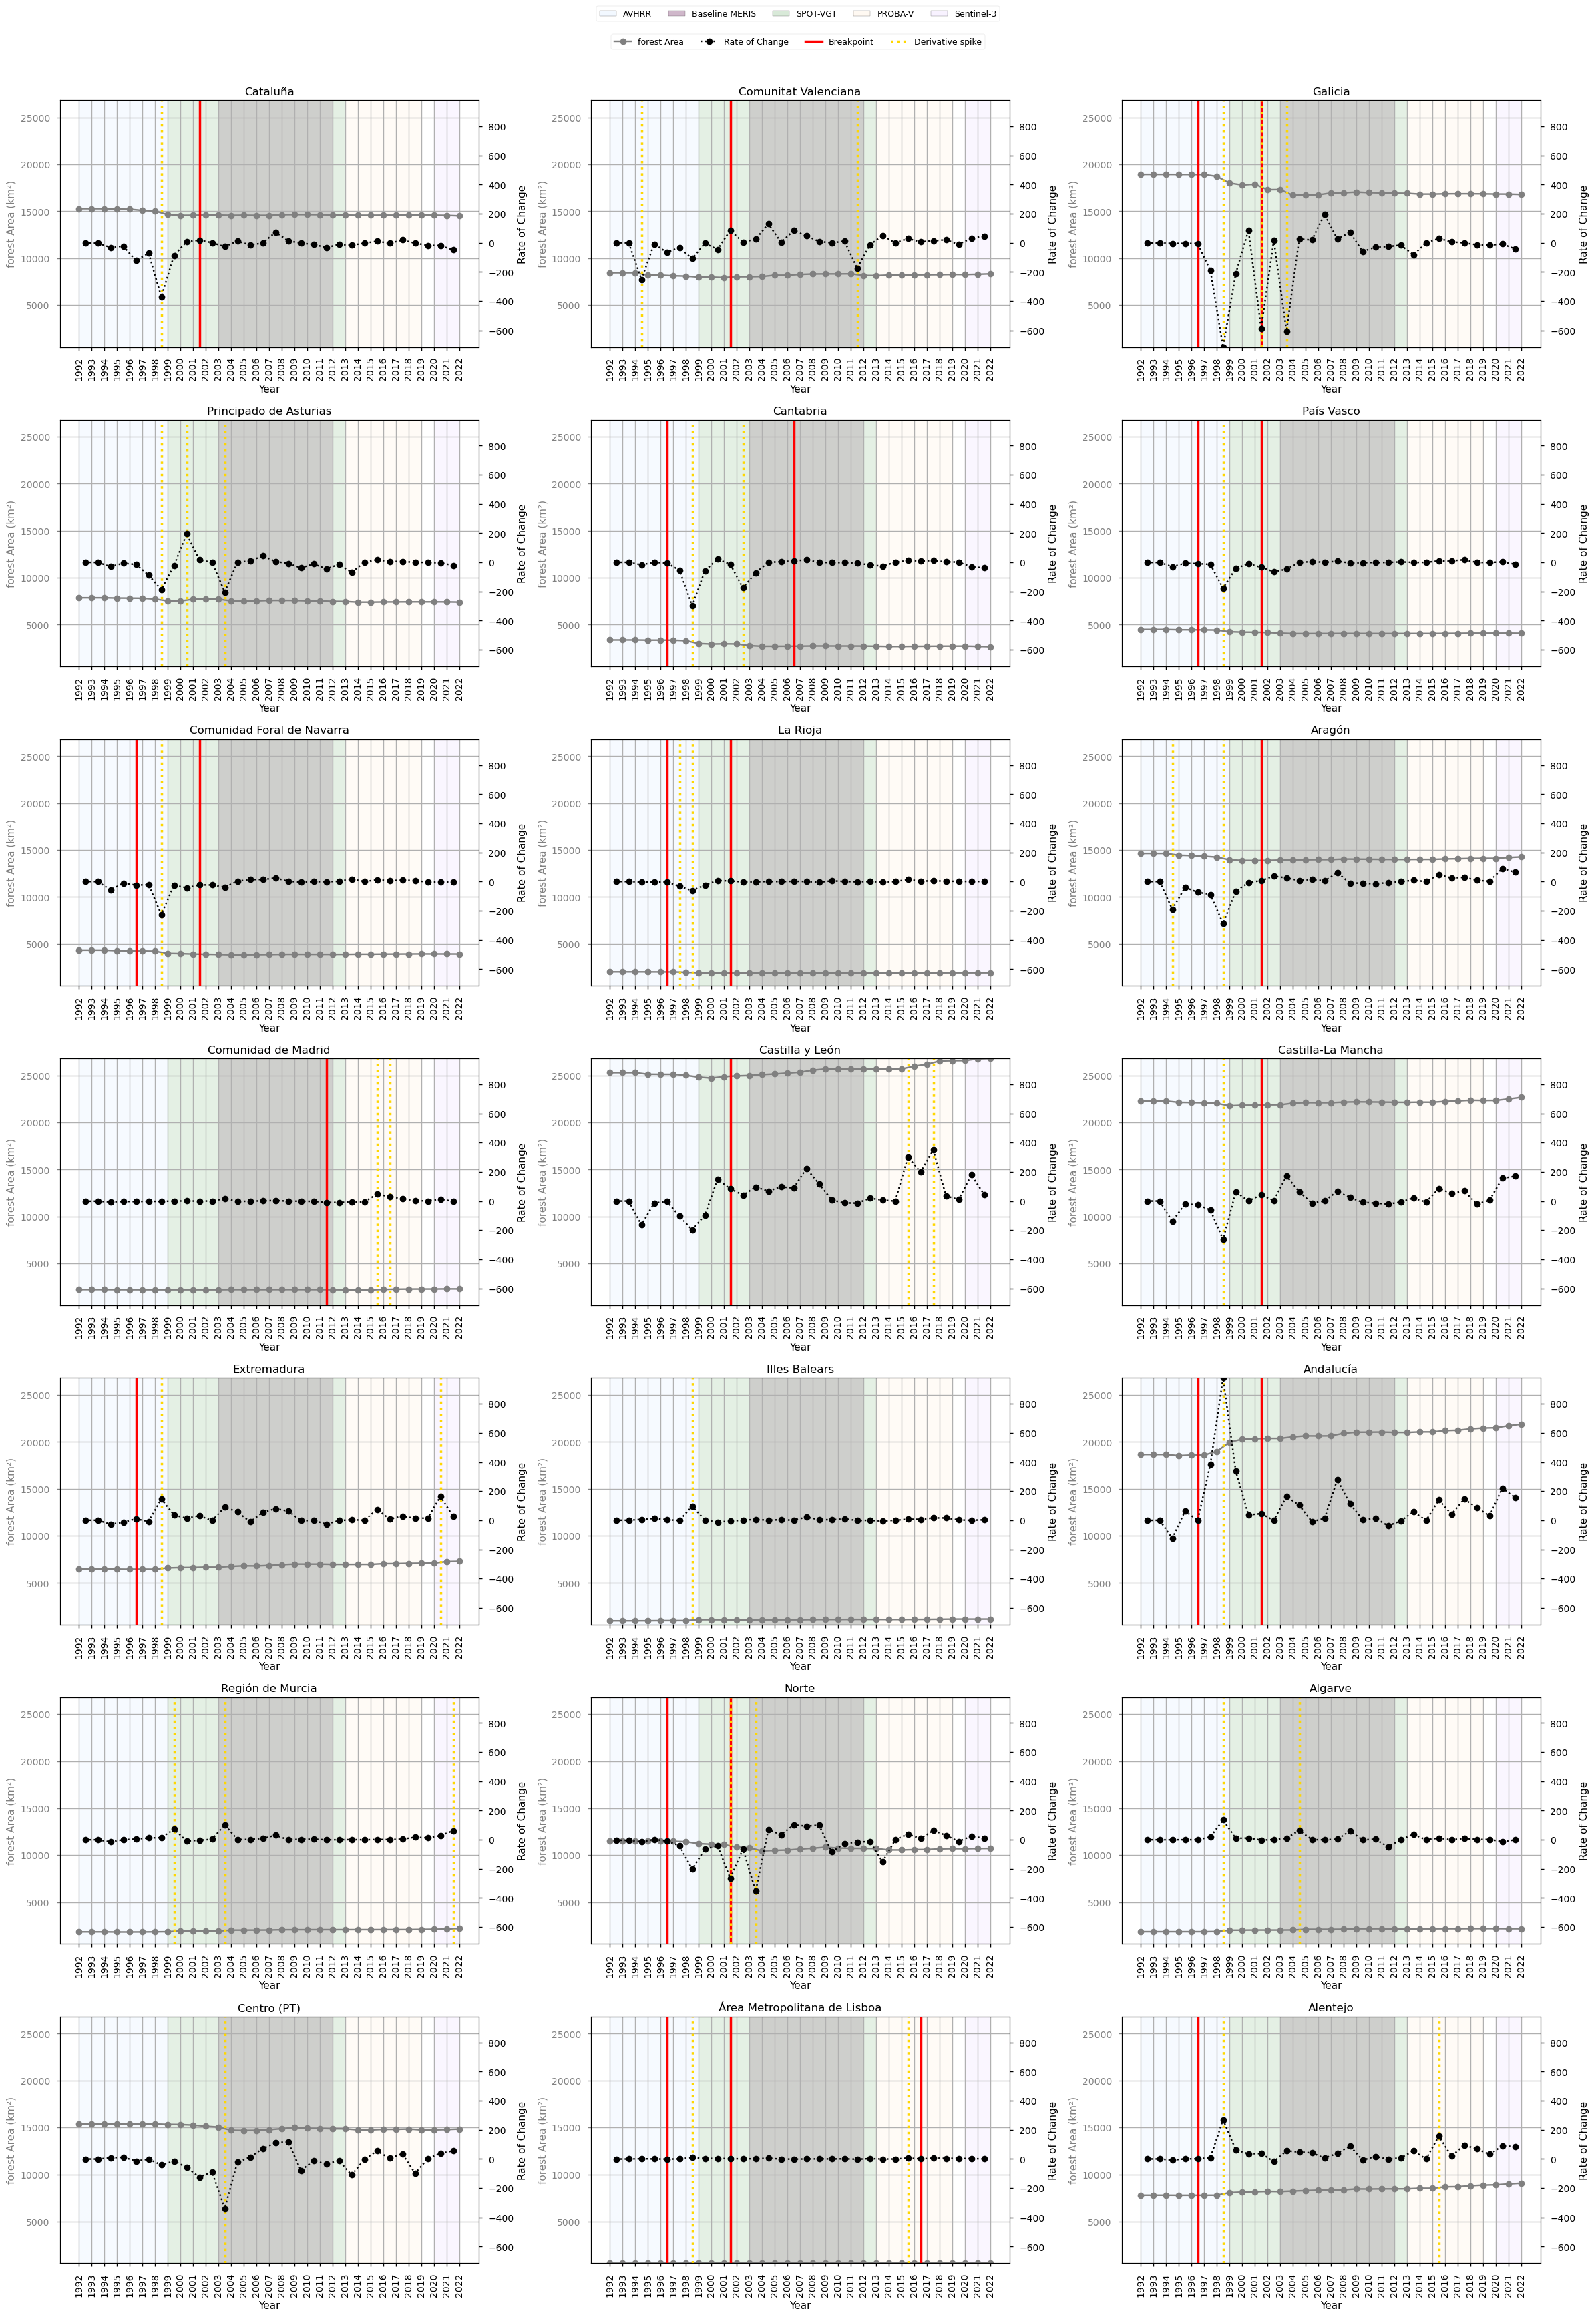

In [12]:
# Plot Breakpoints Series
n_rows = int(np.ceil(n_regions / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 8, n_rows * 5), squeeze=False)
axes = axes.flatten()

for idx, region in enumerate(unique_regions):
    ax = axes[idx]

    region_data = results_df[results_df["Region"] == region].sort_values("Year")
    years = region_data["Year"].to_numpy(dtype=float)
    Forest_Area = region_data["Forest_Area"].to_numpy(dtype=float)

    mono = monotonicity_metrics(Forest_Area)
    monotonicity_records.append({"Region": region, **mono})

    growth, growth_years = compute_growth(years, Forest_Area)
    spike_idx = detect_spikes(growth, spike_std_factor=spike_std_factor)
    breakpoint_idx = detect_breakpoints(
        growth,
        min_size=pelt_min_size,
        penalty=pelt_penalty,
        standardize=standardize_growth
    )

    spike_positions = growth_years[spike_idx] if len(spike_idx) else np.array([])
    breakpoint_positions = growth_years[breakpoint_idx] if len(breakpoint_idx) else np.array([])

    # Store spikes
    for s in spike_idx:
        rec = make_event_record(
            region, years, growth_years, s,
            extra={"Derivative": growth[s]}
        )
        spike_records.append(rec)
        update_counts(
            rec,
            interval_spike_counts,
            phase_spike_counts,
            prepost_spike_counts
        )

    # Store breakpoints
    for bp in breakpoint_idx:
        rec = make_event_record(region, years, growth_years, bp)
        breakpoint_records.append(rec)
        update_counts(
            rec,
            interval_breakpoint_counts,
            phase_breakpoint_counts,
            prepost_breakpoint_counts
        )

    # Background phases
    for phase in processing_phases:
        ax.axvspan(
            phase["start"],
            phase["end"],
            color=phase_colors.get(phase["label"], "lightgrey"),
            alpha=0.35,
            zorder=0
        )

    # Main series
    ax.plot(years, Forest_Area, marker="o", color="grey", zorder=2)
    ax.set_ylabel("forest Area (km²)", color="grey")
    ax.tick_params(axis="y", colors="grey")
    ax.set_ylim(global_y_min, global_y_max)

    # Breakpoints
    for x in breakpoint_positions:
        ax.axvline(
            x,
            color="red",
            linestyle="-",
            linewidth=2.5,
            zorder=4
        )

    # Spikes
    for x in spike_positions:
        ax.axvline(
            x,
            color="gold",
            linestyle=":",
            linewidth=2.5,
            zorder=5
        )

    # Growth rate
    ax2 = ax.twinx()
    ax2.plot(
        growth_years,
        growth,
        marker="o",
        linestyle="dotted",
        color="black",
        zorder=6
    )
    ax2.set_ylabel("Rate of Change", color="black")
    ax2.tick_params(axis="y", colors="black")
    ax2.set_ylim(global_derivative_min, global_derivative_max)

    # Formatting
    ax.set_xticks(years)
    ax.set_xticklabels(years.astype(int), rotation=90)
    ax.set_title(region)
    ax.set_xlabel("Year")
    ax.grid()

# Remove empty axes
for idx in range(n_regions, len(axes)):
    fig.delaxes(axes[idx])


# Processing phases legend
phase_handles = [
    Patch(
        facecolor=phase_colors[p["label"]],
        edgecolor="black",
        alpha=0.5,
        label=p["label"]
    )
    for p in processing_phases
]

legend_phases = fig.legend(
    handles=phase_handles,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.992),
    ncol=len(processing_phases),
    frameon=True,
    fontsize=9,
    title_fontsize=10
)

# Line/signal legend
line_handles = [
    Line2D([0], [0], color="grey", marker="o", linestyle="-", label="forest Area"),
    Line2D([0], [0], color="black", marker="o", linestyle="dotted", label="Rate of Change"),
    Line2D([0], [0], color="red", linestyle="-", linewidth=2.5, label="Breakpoint"),
    Line2D([0], [0], color="gold", linestyle=":", linewidth=2.5, label="Derivative spike"),
]

legend_lines = fig.legend(
    handles=line_handles,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.98),
    ncol=len(line_handles),
    frameon=True,
    fontsize=9,
    title_fontsize=10
)

# Compact spacing between legends and plots
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

In [13]:
# Plot the aligned breakpoints and derivative spikes with known methodological changes present in more than half of the regions

sensors_timeline = {
    "AVHRR_finish": [1999],
    "SPOT-VGT_start": [1999],
    "SPOT-VGT_finish": [2013],
    "MERIS_baseline_start": [2003],
    "MERIS_baseline_finish": [2012],
    "PROBAV_start": [2013],
    "S3_OLCI_start": [2020],
    "S3_OLCI_SLSTR_start": [2021],
}

forward_window = 2.0
min_regions = 10  # threshold for strong/systematic signal

breakpoint_df = pd.DataFrame(breakpoint_records)
spike_df = pd.DataFrame(spike_records)

def classify_transition_relation(year):
    matches = []
    for name, years in sensors_timeline.items():
        for t in years:
            if 0 < (year - t) <= forward_window:
                matches.append(f"{name} ({t})")
    return "; ".join(matches) if matches else "None within 2 years"


def build_summary(df):
    if df.empty:
        return pd.DataFrame(columns=[
            "intervals",
            "number of regions",
            "regions name",
            "nearest processing changes",
        ])

    summary = (
        df.groupby("Interval")
        .agg(
            **{
                "number of regions": ("Region", "nunique"),
                "regions name": ("Region", lambda x: ", ".join(sorted(set(x)))),
                "mean_year": ("Year", "mean"),
            }
        )
        .reset_index()
    )

    # Rename Interval column
    summary = summary.rename(columns={"Interval": "intervals"})

    # Add relation to processing transition
    summary["nearest processing changes"] = summary["mean_year"].apply(classify_transition_relation)

    # Drop helper column
    summary = summary.drop(columns=["mean_year"])

    # Sort by number of regions, then by interval
    summary = summary.sort_values(
        ["number of regions", "intervals"],
        ascending=[False, True]
    ).reset_index(drop=True)

    return summary


# Build tables
bp_event_summary = build_summary(pd.DataFrame(breakpoint_records))
spike_event_summary = build_summary(pd.DataFrame(spike_records))

# Display nicely
pd.set_option("display.max_colwidth", None)

print("### Breakpoint Table ###")
display(bp_event_summary)

print("### Derivative Spike Table ###")
display(spike_event_summary)

### Breakpoint Table ###


,intervals,number of regions,regions name,nearest processing changes
0,2001-2002,12,"Andalucía, Aragón, Castilla y León, Castilla-La Mancha, Cataluña, Comunidad Foral de Navarra, Comunitat Valenciana, Galicia, La Rioja, Norte, País Vasco, Área Metropolitana de Lisboa",None within 2 years
1,1996-1997,10,"Alentejo, Andalucía, Cantabria, Comunidad Foral de Navarra, Extremadura, Galicia, La Rioja, Norte, País Vasco, Área Metropolitana de Lisboa",None within 2 years
2,2006-2007,1,Cantabria,None within 2 years
3,2011-2012,1,Comunidad de Madrid,None within 2 years
4,2016-2017,1,Área Metropolitana de Lisboa,None within 2 years


### Derivative Spike Table ###


,intervals,number of regions,regions name,nearest processing changes
0,1998-1999,15,"Alentejo, Algarve, Andalucía, Aragón, Cantabria, Castilla-La Mancha, Cataluña, Comunidad Foral de Navarra, Extremadura, Galicia, Illes Balears, La Rioja, País Vasco, Principado de Asturias, Área Metropolitana de Lisboa",None within 2 years
1,2003-2004,5,"Centro (PT), Galicia, Norte, Principado de Asturias, Región de Murcia",MERIS_baseline_start (2003)
2,2015-2016,4,"Alentejo, Castilla y León, Comunidad de Madrid, Área Metropolitana de Lisboa",None within 2 years
3,1994-1995,2,"Aragón, Comunitat Valenciana",None within 2 years
4,2001-2002,2,"Galicia, Norte",None within 2 years
5,1997-1998,1,La Rioja,None within 2 years
6,1999-2000,1,Región de Murcia,AVHRR_finish (1999); SPOT-VGT_start (1999)
7,2000-2001,1,Principado de Asturias,AVHRR_finish (1999); SPOT-VGT_start (1999)
8,2002-2003,1,Cantabria,None within 2 years
9,2004-2005,1,Algarve,MERIS_baseline_start (2003)


#### Breakpoint and Derivative-Spike Analysis

Breakpoint detection and derivative analysis describe related but not identical aspects of temporal change in land-cover time series. Breakpoints indicate potential structural shifts, while derivative spikes identify years with strong year-to-year variation ([Chelali et al., 2019](https://doi.org/10.1109/JURSE.2019.8808967); [Chang et al., 2018](https://doi.org/10.1088/1755-1315/113/1/012087)). However, the repeated concentration of breakpoints and derivative spikes around similar years suggests that some of the observed variability may reflect methodological sensitivity, rather than clearly separable ecological or land-use processes.

Signals are considered more robust when they show broad spatial coherence across regions, but temporal clustering alone is not treated as evidence of multiple independent change events. In satellite-derived land-cover products, changes in sensors, classification schemes, reference layers, or processing chains can introduce apparent discontinuities or amplified year-to-year variation. Therefore, breakpoint and derivative-spike results are assessed together, with attention to both spatial consistency and possible methodological artefacts ([Chang et al., 2018](https://doi.org/10.1088/1755-1315/113/1/012087)).

The **1998–1999 derivative signal**, affecting 15 regions, is the most spatially widespread short-term variability signal. Its limited correspondence with a clear breakpoint suggests that it may represent transient variability, classification sensitivity in mixed or transitional land-cover classes, or early inconsistencies in the time series.

A major breakpoint cluster is also observed around **2001–2002**, affecting 12 regions. Although this is the most spatially coherent breakpoint signal, no clearly documented methodological transition is identified within a close temporal window. This weakens any direct attribution to a known processing-chain change. The signal may partly reflect real land-cover dynamics, including wildfire activity, forest management changes, or broader land-use transitions in the Iberian Peninsula [(Silva et al., 2011)](https://doi.org/10.1016/j.landurbplan.2011.03.001). Nevertheless, because breakpoint and derivative signals cluster around nearby years, this period is best interpreted as a strong but not fully attributable signal, potentially combining environmental change with methodological effects.

A secondary derivative signal occurs around **2003–2004**, affecting 5 regions. This timing coincides with major wildfire activity and forest loss in parts of the Iberian Peninsula [(Mato et al., 2014)](https://api.semanticscholar.org/CorpusID:265869582), as well as improvements in detection capacity. 

An earlier breakpoint cluster around **1996–1997**, affecting 10 regions, suggests a possible structural shift in western and northern regions. Its timing is consistent with broader land-use transitions, including farmland abandonment and natural forest regeneration [(Palmero-Iniesta et al., 2021)](https://api.semanticscholar.org/CorpusID:238829360), as well as changes in forest management. However, given its proximity to the stronger 1998–1999 derivative signal, it should not be treated as a fully independent event without further validation.

Overall, the recurrence of breakpoint and derivative-spike detections around similar years indicates that the time series contains periods of heightened instability, but these should not be over-interpreted as discrete ecological events. The most defensible interpretation is that the late 1990s to early 2000s represent an interval of elevated variability possibly shaped by a combination of land-cover change, disturbance processes, and methodological sensitivity in the data product.

Additional breakpoint and derivative-spike detections affect only a small number of regions. These are best interpreted as localised or context-specific dynamics, potentially linked to wildfires, drought impacts, regional land-use change, plantation dynamics, or natural regeneration following abandonment [(Gouveia et al., 2012](https://nhess.copernicus.org/articles/12/3123/2012/)[; Vidal-Macua et al., 2017)](https://doi.org/10.1016/j.foreco.2017.10.011); [(Silva et al., 2011)](https://doi.org/10.1016/j.landurbplan.2011.03.001); [(Palmero-Iniesta et al., 2021)](https://api.semanticscholar.org/CorpusID:238829360).

(satellite_satellite-land-cover_completeness_q03:code-section-4)=
### **4. Trend Assessment**

The next and final step is to determine whether the trend should be computed for the entire period (total trend) or divided into segments based on detected breakpoints.

The decision between using the total trend or segmented trends is based on Sen’s Slope (Trend Magnitude) and Mann-Kendall p-values (Trend Significance). Sen’s Slope is a non-parametric estimator that calculates the median rate of change over time, making it robust to outliers. First, Sen’s Slope is computed for the total trend, capturing the overall rate of forest change. Then, Sen’s Slope is calculated for each segmented trend to assess whether breakpoints introduce significant shifts in trend magnitude. The Mann-Kendall test is a non-parametric statistical test used to assess the presence of upward or downward trend in a time series without requiring the data to follow any particular distribution. In parallel, the Mann-Kendall p-value is evaluated for both the total and segmented trends to measure trend significance—lower p-values indicate stronger evidence of a significant trend.

The final decision is based on the following approach:

- If segmented trends show substantially different Sen’s Slopes compared to the total trend and exhibit stronger statistical significance (lower p-values), segmentation is preferred.
- If segmented trends closely resemble the total trend or do not provide a clear statistical advantage, the total trend is used to maintain a simpler and more robust interpretation.

In [14]:
# Prepare data for trend calculation

breakpoints_df = pd.DataFrame(breakpoint_records).copy()
breakpoints_df["Year"] = pd.to_numeric(breakpoints_df["Year"], errors="coerce").round().astype("Int64")

results_df = results_df.copy()
results_df["Year"] = pd.to_numeric(results_df["Year"], errors="coerce")
results_df["Forest_Area"] = pd.to_numeric(results_df["Forest_Area"], errors="coerce")

# Keep only valid rows
results_df = results_df.dropna(subset=["Region", "Year", "Forest_Area"]).copy()
breakpoints_df = breakpoints_df.dropna(subset=["Region", "Year"]).copy()

In [15]:
# Calculate trends

def mann_kendall_p(x):
    """Return Mann-Kendall p-value and trend label."""
    if len(x) < 3:
        return np.nan, "no trend"
    res = mk.original_test(x)
    return res.p, res.trend

def significance_stars(p):
    if pd.isna(p):
        return ""
    if p < 0.001:
        return "***"
    elif p < 0.01:
        return "**"
    elif p < 0.05:
        return "*"
    return ""

def significance_traffic_light(p):
    if pd.isna(p):
        return "Unknown"
    if p < 0.05:
        return "Green"
    elif p < 0.10:
        return "Amber"
    return "Red"

def trend_direction(rate_per_decade, p_value, stable_threshold=0.10):
    """
    Classify overall direction.
    stable_threshold is in percentage points of area per decade.
    """
    if pd.isna(rate_per_decade):
        return "Unknown"
    if (not pd.isna(p_value) and p_value >= 0.05) or abs(rate_per_decade) < stable_threshold:
        return "Stable"
    return "Increase" if rate_per_decade > 0 else "Decrease"

def material_segmentation_change(total_direction, total_rate_decade, segment_rows):
    """
    Returns Yes if at least one significant segment changes the conclusion materially.
    Conservative logic:
    - any significant segment with opposite direction to total
    - OR strongest significant segment is >1.5x total magnitude and opposite sign
    """
    if segment_rows.empty:
        return "No"
    
    sig = segment_rows[segment_rows["MK_P_Value"] < 0.05].copy()
    if sig.empty:
        return "No"
    
    for _, r in sig.iterrows():
        seg_dir = r["Direction"]
        if total_direction in ["Increase", "Decrease"] and seg_dir in ["Increase", "Decrease"]:
            if seg_dir != total_direction:
                return "Yes"
    
    return "No"

def confidence_label(n_breakpoints, segmentation_changes, total_p, total_rate_decade):
    """
    Reviewer asks for confidence considering breakpoints and local drivers.
    Since local drivers are not encoded in this table, use a transparent rule:
    - High: significant total trend, no material segmentation change, <=1 breakpoint
    - Medium: significant total trend but segmentation change or multiple breakpoints
    - Low: non-significant total trend or unstable segmented interpretation
    """
    if pd.isna(total_p):
        return "Low"
    if total_p >= 0.05:
        return "Low"
    if segmentation_changes == "No" and n_breakpoints <= 1:
        return "High"
    return "Medium"


# Compute total + segmented trends 

trend_records = []

for region in results_df["Region"].dropna().unique():
    region_data = results_df.loc[results_df["Region"] == region].sort_values("Year").copy()
    X_total = region_data["Year"].values
    y_total = region_data["Forest_Area"].values

    if len(region_data) < 3 or np.isnan(y_total).any():
        continue

    # Total Sen slope
    total_sen_slope, _, _, _ = theilslopes(y_total, X_total)

    # Convert to % area per decade, as requested by reviewer
    mean_total_area = np.mean(y_total)
    total_rate_pct_per_year = (total_sen_slope / mean_total_area) * 100 if mean_total_area != 0 else np.nan
    total_rate_pct_per_decade = total_rate_pct_per_year * 10 if pd.notna(total_rate_pct_per_year) else np.nan

    # Mann-Kendall
    total_p_value, total_mk_trend = mann_kendall_p(y_total)
    total_direction = trend_direction(total_rate_pct_per_decade, total_p_value)

    trend_records.append({
        "Region": region,
        "Type": "Total",
        "Start_Year": int(region_data["Year"].min()),
        "End_Year": int(region_data["Year"].max()),
        "Sen_Slope": round(total_sen_slope, 6),
        "Rate_of_Change_pct_per_year": round(total_rate_pct_per_year, 6) if pd.notna(total_rate_pct_per_year) else np.nan,
        "Rate_of_Change_pct_per_decade": round(total_rate_pct_per_decade, 6) if pd.notna(total_rate_pct_per_decade) else np.nan,
        "MK_P_Value": total_p_value,
        "MK_Trend": total_mk_trend,
        "Direction": total_direction,
        "Significance_Stars": significance_stars(total_p_value),
        "Traffic_Light": significance_traffic_light(total_p_value),
        "Segment_Length": len(region_data)
    })

    # Breakpoints and segmented trends
    region_breakpoints = (
        breakpoints_df.loc[breakpoints_df["Region"] == region, "Year"]
        .dropna()
        .astype(int)
        .tolist()
    )
    bounds = sorted(set([int(region_data["Year"].min())] + region_breakpoints + [int(region_data["Year"].max())]))

    for i in range(len(bounds) - 1):
        start_year, end_year = bounds[i], bounds[i + 1]
        segment_data = region_data[(region_data["Year"] >= start_year) & (region_data["Year"] <= end_year)].copy()

        if len(segment_data) < 3:
            continue

        X_seg = segment_data["Year"].values
        y_seg = segment_data["Forest_Area"].values

        seg_sen_slope, _, _, _ = theilslopes(y_seg, X_seg)

        mean_seg_area = np.mean(y_seg)
        seg_rate_pct_per_year = (seg_sen_slope / mean_seg_area) * 100 if mean_seg_area != 0 else np.nan
        seg_rate_pct_per_decade = seg_rate_pct_per_year * 10 if pd.notna(seg_rate_pct_per_year) else np.nan

        seg_p_value, seg_mk_trend = mann_kendall_p(y_seg)
        seg_direction = trend_direction(seg_rate_pct_per_decade, seg_p_value)

        trend_records.append({
            "Region": region,
            "Type": "Segmented",
            "Start_Year": int(start_year),
            "End_Year": int(end_year),
            "Sen_Slope": round(seg_sen_slope, 6),
            "Rate_of_Change_pct_per_year": round(seg_rate_pct_per_year, 6) if pd.notna(seg_rate_pct_per_year) else np.nan,
            "Rate_of_Change_pct_per_decade": round(seg_rate_pct_per_decade, 6) if pd.notna(seg_rate_pct_per_decade) else np.nan,
            "MK_P_Value": seg_p_value,
            "MK_Trend": seg_mk_trend,
            "Direction": seg_direction,
            "Significance_Stars": significance_stars(seg_p_value),
            "Traffic_Light": significance_traffic_light(seg_p_value),
            "Segment_Length": len(segment_data)
        })

trends_df = pd.DataFrame(trend_records)

The following summary table reports:

- **Growth rate (%/decade)** → long-term rate of forest expansion  
- **Significance** → statistical robustness of the full trend 
    - `***` → highly significant (p < 0.001)  
    - `**` → significant (p < 0.01)  
    - `*` → moderately significant (p < 0.05)  
    - no symbol → not statistically significant  
- **Breakpoints** → number of structural changes detected  
- **Segmented trend needed?** → whether segmented trends change the interpretation  
- **Confidence** → degree of agreement between full and segmented trend significance  

In [16]:
# Build summary table

summary_rows = []

latest_year = results_df["Year"].astype(int).max()

# forest area for each region in the latest year
area_per_region = (
    results_df.loc[results_df["Year"].astype(int) == latest_year, ["Region", "Forest_Area"]]
    .drop_duplicates(subset=["Region"])
    .set_index("Region")["Forest_Area"]
)

def confidence_label(total_p_value, segment_rows):
    """
    Confidence based on agreement between the significance
    of the full trend and the segmented trends.

    Rules:
    - Low: full trend is not significant
    - High: full trend is significant and all segmented trends are significant
    - Medium: full trend is significant but segmented trends are mixed or weaker
    """
    if pd.isna(total_p_value):
        return "Low"

    if total_p_value >= 0.05:
        return "Low"

    if segment_rows.empty:
        return "High"

    valid_segments = segment_rows.dropna(subset=["MK_P_Value"]).copy()

    if valid_segments.empty:
        return "High"

    sig_segments = valid_segments[valid_segments["MK_P_Value"] < 0.05]
    nonsig_segments = valid_segments[valid_segments["MK_P_Value"] >= 0.05]

    if len(sig_segments) == len(valid_segments):
        return "High"

    if len(sig_segments) > 0 and len(nonsig_segments) > 0:
        return "Medium"

    return "Medium"


for region in trends_df["Region"].unique():
    total_row = trends_df[
        (trends_df["Region"] == region) & (trends_df["Type"] == "Total")
    ].iloc[0]

    segment_rows = trends_df[
        (trends_df["Region"] == region) & (trends_df["Type"] == "Segmented")
    ].copy()

    n_breakpoints = breakpoints_df.loc[
        breakpoints_df["Region"] == region, "Year"
    ].nunique()

    seg_changes = material_segmentation_change(
        total_direction=total_row["Direction"],
        total_rate_decade=total_row["Rate_of_Change_pct_per_decade"],
        segment_rows=segment_rows
    )

    confidence = confidence_label(
        total_p_value=total_row["MK_P_Value"],
        segment_rows=segment_rows
    )

    summary_rows.append({
        "Region": region,
        "Total forest area (km²)": area_per_region.get(region, np.nan),
        "Growth rate (%/decade)": total_row["Rate_of_Change_pct_per_decade"],
        "Significance": total_row["Significance_Stars"],
        "Breakpoints": int(n_breakpoints) if pd.notna(n_breakpoints) else 0,
        "Segmented trend needed?": seg_changes,
        "Confidence": confidence
    })

executive_summary_df = pd.DataFrame(summary_rows)

# Sort by growth rate
executive_summary_df = executive_summary_df.sort_values(
    "Growth rate (%/decade)", ascending=False
).reset_index(drop=True)

# Round for display
executive_summary_df["Growth rate (%/decade)"] = executive_summary_df["Growth rate (%/decade)"].round(1)
executive_summary_df["Total forest area (km²)"] = executive_summary_df["Total forest area (km²)"].round(0)

# Normalize text values
executive_summary_df["Segmented trend needed?"] = executive_summary_df["Segmented trend needed?"].map({
    "Yes": "Yes",
    "No": "No"
}).fillna("No")

executive_summary_df["Confidence"] = executive_summary_df["Confidence"].fillna("Low")
executive_summary_df["Significance"] = executive_summary_df["Significance"].fillna("")

n_regions = len(executive_summary_df)
n_seg_no = (executive_summary_df["Segmented trend needed?"] == "No").sum()
n_high = (executive_summary_df["Confidence"] == "High").sum()
n_medium = (executive_summary_df["Confidence"] == "Medium").sum()
n_low = (executive_summary_df["Confidence"] == "Low").sum()

print(
    f"{n_regions} regions were assessed. "
    f"Segmented trends are not required in {n_seg_no} of {n_regions} regions. "
    f"Confidence is High in {n_high} regions, Medium in {n_medium}, and Low in {n_low}."
)


# HTML table display

def color_significance(val):
    if val == "***":
        return "background-color: #e2f0d9; color: #1f4d1f; font-weight: bold;"
    elif val == "**":
        return "background-color: #fff2cc; color: #7f6000; font-weight: bold;"
    elif val == "*":
        return "background-color: #fce5cd; color: #7f3f00; font-weight: bold;"
    return ""

def color_segmented(val):
    if val == "No":
        return "background-color: #e2f0d9; color: #1f4d1f; font-weight: bold;"
    elif val == "Yes":
        return "background-color: #f4cccc; color: #990000; font-weight: bold;"
    return ""

def color_confidence(val):
    if val == "High":
        return "background-color: #d9ead3; color: #1f4d1f; font-weight: bold;"
    elif val == "Medium":
        return "background-color: #fff2cc; color: #7f6000; font-weight: bold;"
    elif val == "Low":
        return "background-color: #f4cccc; color: #990000; font-weight: bold;"
    return ""

def growth_bar(val, vmin, vmax):
    if pd.isna(val):
        return ""
    pct = 100 if vmax == vmin else 100 * (val - vmin) / (vmax - vmin)
    return f"background: linear-gradient(90deg, #9fc5e8 {pct:.1f}%, transparent {pct:.1f}%); text-align: center;"

def display_executive_summary_table(df):
    df_display = df.copy()
    vmin = df_display["Growth rate (%/decade)"].min()
    vmax = df_display["Growth rate (%/decade)"].max()

    def style_row(row):
        styles = []
        for col, val in row.items():
            base = "padding: 6px 8px; border: 1px solid #ccc;"
            if col == "Region":
                base += " text-align: left; font-weight: bold;"
            else:
                base += " text-align: center;"

            if col == "Significance":
                base += color_significance(val)
            elif col == "Segmented trend needed?":
                base += color_segmented(val)
            elif col == "Confidence":
                base += color_confidence(val)
            elif col == "Growth rate (%/decade)":
                base += growth_bar(val, vmin, vmax)

            styles.append(base)
        return styles

    styled = df_display.style.format({
        "Total forest area (km²)": "{:.0f}",
        "Growth rate (%/decade)": "{:.1f}"
    }).apply(style_row, axis=1)

    html = styled.to_html()

    wrapped_html = f"""
    <div style="overflow-x:auto;">
        <style>
            table {{
                border-collapse: collapse;
                width: 100%;
                font-size: 13px;
            }}
            th {{
                background-color: #f2f2f2;
                border: 1px solid #ccc;
                padding: 6px 8px;
                text-align: center;
            }}
        </style>
        {html}
    </div>
    """

    display(HTML(wrapped_html))

display_executive_summary_table(executive_summary_df)

21 regions were assessed. Segmented trends are not required in 18 of 21 regions. Confidence is High in 10 regions, Medium in 7, and Low in 4.


,Region,Total forest area (km²),Growth rate (%/decade),Significance,Breakpoints,Segmented trend needed?,Confidence
0,Región de Murcia,2184,5.6,***,0,No,High
1,Algarve,2156,5.4,***,0,No,High
2,Illes Balears,1142,5.1,***,0,No,High
3,Alentejo,9064,4.9,***,1,No,Medium
4,Andalucía,21880,4.2,***,2,No,Medium
5,Extremadura,7262,4.0,***,1,No,Medium
6,Área Metropolitana de Lisboa,606,2.6,***,3,No,Medium
7,Castilla y León,26809,2.4,***,1,Yes,High
8,Comunitat Valenciana,8335,0.7,,1,No,Low
9,Castilla-La Mancha,22665,0.6,***,1,Yes,High


#### Trend Analysis

The results demonstrate that while breakpoints exist, whether driven by real environmental changes or influenced by sensor/methodological shifts, they do not necessarily require separate trend calculations. In most cases, the total trend provides a stable and reliable representation of forest evolution across the full dataset, reinforcing the idea that forest cover follows a largely continuous trajectory over time.

However, certain regions exhibit segmented trends that deviate significantly from the total trend. These cases merit special attention, as they may reflect actual shifts in forest dynamics due to land management, climate events, or localised disturbances. 

A key consideration is the geographical and ecological diversity of the Iberian Peninsula. Larger regions with varied landscapes may show more gradual changes in forest cover, making the total trend more representative. In contrast, smaller or ecologically distinct regions may experience more abrupt shifts that justify the use of segmented trends in specific cases.

Ultimately, while breakpoints provide useful insights into short-term variations, they do not invalidate the overall trend. This analysis confirms that long-term forest trends in the Iberian Peninsula can be effectively assessed using the full dataset, with segmentation being relevant only when trends deviate sharply and are supported by contextual or statistical evidence.

(satellite_satellite-land-cover_completeness_q03:code-section-5)=
### **5. Discussion**

The results of this analysis highlight the value of the dataset for monitoring forest dynamics in the Iberian Peninsula. The dataset proves robust for long-term trend detection, with methodological transitions and sensor shifts,having none to limited impact on overarching patterns of forest change.

For applications in spatial planning and land management, this consistency is crucial. The ability to track forest evolution across decades allows regional planners and policymakers to evaluate the outcomes of afforestation policies, conservation efforts, and land abandonment. Even in the presence of minor reclassifications or local anomalies, the dataset supports confident assessments of broader land cover trends.

Nonetheless, the analysis also underscores the importance of methodological awareness. Breakpoints, particularly those associated with known sensor transitions, can introduce artificial changes in the time series. These do not necessarily reflect ecological shifts but rather improvements in resolution, classification algorithms, or spectral capabilities. Users must remain cautious when interpreting abrupt changes without considering the underlying data lineage.

Geographic context further shapes interpretability. Larger, heterogeneous regions tend to smooth out classification noise, while smaller or fragmented areas may reflect sharper, localized breaks. This has direct implications for regional land management strategies, where scale and land use diversity influence the reliability of detected trends.

In practical terms, the dataset is well-suited for identifying general trends in forest cover, but users should:

- Complement statistical analysis with contextual information (e.g., known policy events, fire records),
- Use segmentation carefully—reserving it for regions with strong evidence of structural change,
- Remain cautious when interpreting data near known sensor transition years.

In conclusion, the dataset provides a strong foundation for forest monitoring and planning. However, optimal use requires not just quantitative analysis, but also critical interpretation of when and why changes appear in the data. This fusion of methods and context is essential for informed decision-making in land and forest management.

## ℹ️ If you want to know more

### Key Resources

* The CDS catalogue entry for the data used was [Land cover classification gridded maps from 1992 to present derived from satellite observations](https://cds.climate.copernicus.eu/datasets/satellite-land-cover?tab=overview)

* Product User Guide and Specification of the dataset [version 2.1](https://dast.copernicus-climate.eu/documents/satellite-land-cover/D5.3.1_PUGS_ICDR_LC_v2.1.x_PRODUCTS_v1.1.pdf) and [version 2.0](https://dast.copernicus-climate.eu/documents/satellite-land-cover/D3.3.11-v1.0_PUGS_CDR_LC-CCI_v2.0.7cds_Products_v1.0.1_APPROVED_Ver1.pdf) 

* [Eurostat NUTS](https://ec.europa.eu/eurostat/web/nuts) (Nomenclature of territorial units for statistics)

* [C3S EQC custom functions](https://github.com/bopen/c3s-eqc-automatic-quality-control/tree/main/c3s_eqc_automatic_quality_control), c3s_eqc_automatic_quality_control, prepared by [B-Open](https://www.bopen.eu/)



### References
- [EUROSTAT: Forests, forestry and logging](https://ec.europa.eu/eurostat/statistics-explained/index.php?title=Forests,_forestry_and_logging)

- [New EU Forest Strategy for 2030](https://commission.europa.eu/document/cf3294e1-8358-4c93-8de4-3e1503b95201_en)

- [Mato, M.M., Legido, J.L., Miguez, E., Carballas, T., Jiménez, E., Caselles, V., & Andrade, M.I. (2014). Analysis of burnt areas and number of forest fires in the Iberian Peninsula.](https://api.semanticscholar.org/CorpusID:265869582)

- [Silva, J., Vaz, P.G., Moreira, F., Catry, F.X., & Rego, F.C. (2011). Wildfires as a major driver of landscape dynamics in three fire-prone areas of Portugal. *Landscape and forest Planning, 101*, 349-358.](https://api.semanticscholar.org/CorpusID:83540326)

- [Gouveia, C.M., Bastos, A., Trigo, R.M., & DaCamara, C.C. (2012). Drought impacts on vegetation in the pre- and post-fire events over Iberian Peninsula. *Natural Hazards and Earth System Sciences, 12*, 3123-3137.](https://nhess.copernicus.org/articles/12/3123/2012/)

- [Vidal-Macua, J.J., Ninyerola, M., Zabala, A., Domingo‐Marimon, C., & Pons, X. (2017). Factors affecting forest dynamics in the Iberian Peninsula from 1987 to 2012: the role of topography and drought. *Forest Ecology and Management, 406*, 290-306.](https://doi.org/10.1016/j.foreco.2017.10.011)

- [Sevillano, E.H., Contador, J.F., Schnabel, S., Pulido, M., & Ibáñez, J.Q. (2018). Using spatial models of temporal tree dynamics to evaluate the implementation of EU afforestation policies in rangelands of SW Spain. *Land Use Policy.*](https://doi.org/10.1016/j.landusepol.2018.06.054)

- [Palmero-Iniesta, M., Espelta, J.M., Padial-Iglesias, M., González-Guerrero, Ó., Pesquer, L., Domingo‐Marimon, C., Ninyerola, M., Pons, X., & Pino, J. (2021). The Role of Recent (1985–2014) Patterns of Land Abandonment and Environmental Factors in the Establishment and Growth of Secondary Forests in the Iberian Peninsula. *Land.*](https://api.semanticscholar.org/CorpusID:238829360)

- [Silva, J., Vaz, P.G., Moreira, F., Catry, F.X., & Rego, F.C. (2011). Wildfires as a major driver of landscape dynamics in three fire-prone areas of Portugal. *Landscape and forest Planning, 101*, 349-358.](https://doi.org/10.1016/j.landurbplan.2011.03.001)

- [Regos, A., Ninyerola, M., Moré, G., & Pons, X. (2015). Linking land cover dynamics with driving forces in mountain landscapes of the Northwestern Iberian Peninsula. *Int. J. Appl. Earth Obs. Geoinformation, 38*, 1-14.](https://doi.org/10.1016/j.jag.2014.11.010)

- [Toté, C., Swinnen, E., & Henocq, C. (2024). An Evaluation of Sentinel-3 SYN VGT Products in Comparison to the SPOT/VEGETATION and PROBA-V Archives. Remote Sensing, 16(20), 3822. https://doi.org/10.3390/rs16203822 ](https://doi.org/10.3390/rs16203822)

- [Zhao, T., Zhang, X., Gao, Y., Mi, J., Liu, W., Wang, J., Jiang, M., & Liu, L. (2023). Assessing the Accuracy and Consistency of Six Fine-Resolution Global Land Cover Products Using a Novel Stratified Random Sampling Validation Dataset. Remote Sensing, 15(9)](https://doi.org/10.3390/rs15092285)